In [23]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
from utils.ica_pipeline import preprocess_for_ica, detrend_and_iir_bandpass
from utils.epoch_and_average import revise_annot, eeglab_logic_bin_epoch

import mne

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import seaborn as sns

import time
import math
import re
from collections import namedtuple
from typing import Callable

from sklearn.model_selection import LeaveOneOut, KFold
from sklearn.linear_model import Ridge
import torch

from scipy.stats import ttest_1samp, mode
from statsmodels.stats.multitest import fdrcorrection

from collections import OrderedDict
from IPython.display import clear_output
import warnings

#### As a simplified example, assume
- SOA = 300 ms
- sesponse lag = 700 ms (i.e., <i>allow/model each word-related response over a 700 ms support window</i>)
- sampling frequency = 10 Hz
- no intercept
- no log-transform
Then the <strong>finite impulse response / time-expanded deconvolution design matrix</strong> for Words 1-3 looks like<br><br>

000 ms (W1)&nbsp;&nbsp; [[1, 0, 0, 0, 0, 0, 0],<br>
100 ms &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[0, 1, 0, 0, 0, 0, 0],<br>
200 ms &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[0, 0, 1, 0, 0, 0, 0],<br>
300 ms (W2)&nbsp;&nbsp; [2, 0, 0, 1, 0, 0, 0],<br>
400 ms &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[0, 2, 0, 0, 1, 0, 0],<br>
500 ms &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[0, 0, 2, 0, 0, 1, 0],<br>
<strong>600 ms (W3)&nbsp;&nbsp;[3, 0, 0, 2, 0, 0, 1]</strong>,<br>
700 ms &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[0, 3, 0, 0, 2, 0, 0],<br>
800 ms &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[0, 0, 3, 0, 0, 2, 0]]<br><br>

To add an intercept, simply horizontally stack another 9-by-7 block matrix (to the left) of the matrix above, and replace every non-zero number with 1. Mathematically, this means there's a stable response throughout the entire time series regardless of word position.<br>

> <strong>REMARK 1.</strong> Notice how the row at 700 ms gets the effects of all Words 1-3.<br>

> <strong>REMARK 2.</strong> This is different in structure - though roughly similar in spirit - from "normal" rERP (regression-based event-related potentials) in that in Smith & Kutas, 2015, Brouwer et al., 2020, and Amanda Lin 2023 (no, I am not citing my never-published GitHub repo LOL), each row of the design matrix is a _trial_, and the regression can be computed at every single sampled time point by stacking the response vector temporally into a 2D matrix (and stacked into 3D for each channel). In contrast, a row in a time-expanded deconvolution design matrix is a _sampled time point_, and each predictor is itself a block matrix (instead of a column vector), then trials are vertically stacked.

The goal of this re-analysis pipeline is to show that adding the word position matrix block significantly improves model fit compared to intercept-only (by t-testing $\Delta R^{2}$). This is a <i>model-selection problem</i>, thus making nested CV (cross-validation) the most standard approach.<br><br>

Note also how this structure makes adding <i>frame valence</i> as a predictor not only conceptually (for me still), but also mathematically awkward:
- Suppose we take frame valence as a catecorgical variable (e.g., positive = -1, neutral = 0, negative = 1), then frame valence is identical across all words in that category regardless of position. This means for all words of frame valence x (x = -1, 0, 1), they have the exact same block matrix for the frame valence predictor, which then makes the intercept block matrix redundant as they are just scaled copies of each other. Vertically stacking trials from different frame valence categories might prevent literal rank deficiency / condition number blow-up, but structurally the design is redundant. So now we remove the global intercept, then the design matrix becomes: a different intercept for each frame valence category, but the same word position block matrix across all categories. This is not the "word position effect differs depending on valence" we're looking for.
- Adding frame valence by word position as an interaction is also not wise because even in standard OLS, interaction terms are known to cause collinearity. This is an even bigger concern for deconvolution since our SOA is constant with no jitters, and while Ridge helps with collinearity, it is not magic.
- Mathmatically we <i>could</i> add frame valence as a continuous predictor, which is the least likely to blow up rank / condition number. But this then becomes conceptually hard to interpret:
    - The core of finite-impulse response is to model the effect or response at a per-sampled-time-point level, not at a contexual, whole trial level.
    - Frame valence is fundamentally / essentially a metric that can only be derived <i>after</i> the participant has seen the second-to-last word of the setence. I find it logically awkward to retroactively "predict" online brain responses to Word 1 using a value that won't surface until Word 10.

$\Longrightarrow$<strong> Possible solution: Run the model separately for each frame valence category and test coefficient differences.</strong>
- Need to check sample size -- 80 trials per category per subject may be okay (Ridge is fitted and cross-validated within subject).

In [216]:
DeconvDesignMatrix = namedtuple("DeconvDesignMatrix",
                                    ["predictors", "full", "n_lags", "rank", "singular_vals", "condition_num"])

def build_design(*, soa: float, sfreq: float,
                 n_words: int, n_trials: int,
                 response_lag: float,
                 rank_tol: float=1e-3,
                 intercept: bool=True,
                 verbose: bool=False,
                 **predictors):
    """note that the condition number is the design matrix X's condition number,
    so the model's normal-equation matrix condition number would be squared, i.e.,
    k(X^T X) = k(X)^2"""
    if predictors:
        for p in predictors.values():
            assert p.shape == (n_trials, n_words), "Each predictor must be a numpy array of shape (n_trials, n_words)"
    
    predictors = dict(predictors)
    if intercept:
        predictors = {"intercept": np.ones((n_trials, n_words), dtype=float), **predictors}
    
    ### TODO: need to check math.ceil() vs math.floor() vs int(round())
    # might need to check how decimation is done in mne.Epochs(decim), e.g., end points kept?
    n_time_samples_per_trial = math.ceil(soa * n_words * sfreq)
    n_time_samples = int(n_time_samples_per_trial * n_trials) 
    n_lags = int(round(response_lag * sfreq))
    soa_samples = math.ceil(soa * sfreq)
    if verbose:
        print(f"# time samples per trial = {n_time_samples_per_trial}")
        print(f"response to each sampled time point lasts {n_lags} time points")
    
    matrices = {name: np.zeros((n_time_samples, n_lags), dtype=float) for name in predictors}
    
    positions = range(n_words)
    for i in range(n_trials):
        for j in positions:
            valid_range = min(n_time_samples_per_trial - j * soa_samples, n_lags)
            row = i * n_time_samples_per_trial + j * soa_samples
            for m, p in zip(matrices.values(), predictors.values()):
                m[row : row + valid_range, : valid_range] += p[i, j] * np.eye(valid_range)

    X_full = np.hstack([m for m in matrices.values()])
    rank = np.linalg.matrix_rank(X_full, tol=rank_tol)
    singular_vals = np.linalg.svd(X_full, compute_uv=False)
    condition_num = np.linalg.cond(X_full)

    return DeconvDesignMatrix(matrices, X_full, n_lags, rank, singular_vals, condition_num)

In [13]:
WEIHUN_DIR = "/Users/jowanglin/regression-based_ERP/data/eeg/weihun"
CRYSTAL_DIR = "/Users/jowanglin/regression-based_ERP/data/eeg/crystal"
JY_DIR = "/Users/jowanglin/Word-Position-Effect_BLP-lab/Preprocessing/ica-data/SUBJ020"

warnings.filterwarnings("ignore")

# for JY's
def transform_description(arr: np.ndarray) -> np.ndarray:
    def helper(arr, idx):
        if arr[idx] == "241":
            return "241_pos" if int(arr[idx+1]) in range(1, 16) else "241_neg"
        elif arr[idx] == "242":
            return "242_pos" if int(arr[idx+1]) in range(31, 46) else "242_neg"
        elif arr[idx] == "243":
            return "243_pos" if int(arr[idx+1]) in range(61, 76) else "243_neg"
        elif arr[idx] == "244":
            return "244_pos" if int(arr[idx+1]) in range(91, 106) else "244_neg"
        else:
            return arr[idx]
                
    arr = [a.replace("S", "").strip() for a in arr]
    arr = [a.replace("boundary", "edge") for a in arr]
    arr = [helper(arr, idx) for idx in range(len(arr))]
    return arr

num = 4
raw_file_name = f"subj{str(num).zfill(3)}_EML_YA_run01-12.set"
raw = mne.io.read_raw_eeglab(f"{WEIHUN_DIR}/{raw_file_name}", verbose=False, preload=False)

annot = raw.annotations
df_annot = pd.DataFrame(annot)

fixation = "210"
non_final = "222"
pos = ("231", "232")
neu = ("233", "234")
neg = ("235", "236", "237", "238")

annot_revised = revise_annot(df_annot,
                             fixation=fixation,
                             non_final=non_final,
                             codes_after_fixation_are_final=True,
                             transform_description=lambda arr: [a.replace("boundary", "edge") for a in arr],
                             pos=pos,
                             neu=neu,
                             neg=neg)

# JY's
#num = 20
#raw_file_name = f"subj{str(num).zfill(3)}.set"
#raw = mne.io.read_raw_eeglab(f"{JY_DIR}/{raw_file_name}", verbose=False, preload=False)

#annot = raw.annotations
#df_annot = pd.DataFrame(annot)

#fixation = "251"
#non_final = "255"
#pos = ("241_pos", "242_pos", "243_pos", "244_pos")
#neu = ("245", "246", "247", "248")
#neg = ("241_neg", "242_neg", "243_neg", "244_neg")

#annot_revised = revise_annot(df_annot,
                             #fixation=fixation,
                             #non_final=non_final,
                             #codes_after_fixation_are_final=False, 
                             #transform_description=transform_description,
                             #pos=pos,
                             #neu=neu,
                             #neg=neg)


In [14]:
raw.load_data()
raw_reref = preprocess_for_ica(raw.copy(),
                               ref_channels={"M2": 0.5},
                               return_raw_reref_only=True)
print(set(raw_reref.get_channel_types()))

# sanity check the reref is correct
data = raw.get_data()
eeg_ch_idx = [i for i, ch in enumerate(raw.ch_names) if "EO" not in ch]
print(np.array_equal((data - data[raw.ch_names.index("M2")]/2)[eeg_ch_idx],
                      raw_reref.get_data(picks="eeg")))

raw_reref_filt = detrend_and_iir_bandpass(raw_reref,
                                          l_freq=0.1, h_freq=30.0,
                                          order=2,
                                          ftype="butter")
raw_reref_filt.set_annotations(annot_revised)
df_annot_revised = pd.DataFrame(raw_reref_filt.annotations)
display(df_annot_revised.head(24))

Reading 0 ... 2682479  =      0.000 ...  2682.479 secs...
standard_montage is not provided; defaulting to MNE-shipped standard_1020 and renaming all channel names to upper case.
{'eeg', 'eog'}
True
Creating RawArray with float64 data, n_channels=33, n_times=2682480
    Range : 0 ... 2682479 =      0.000 ...  2682.479 secs
Ready.


,onset,duration,description,orig_time,extras
0,6.553,0.0,210,None,{}
1,7.570,0.0,w1/neg,None,{}
2,7.936,0.0,w2/neg,None,{}
3,8.303,0.0,w3/neg,None,{}
4,8.669,0.0,w4/neg,None,{}
5,9.036,0.0,w5/neg,None,{}
6,9.402,0.0,w6/neg,None,{}
7,9.769,0.0,w7/neg,None,{}
8,10.136,0.0,235,None,{}
9,10.335,0.0,1,None,{}


In [15]:
n_trials = len([s for s in list(df_annot_revised["description"]) if s.startswith("w1/")])
print(f"N_TRIALS = {n_trials} trials")
SOA = mode(np.diff(df_annot_revised["onset"].to_numpy())).mode
print(f"SOA = {SOA} seconds")
DOWNSAMPLE_SFREQ = 100.0  
N_WORDS = 7

RIDGE_TOL = 1e-5
MAX_ITER = 20000
RANDOM_STATE = 42

N_TRIALS = 208 trials
SOA = 0.36599999999998545 seconds


In [16]:
conditions_list = [dict(pos=("231", "232"),
                        neu=("233", "234"),
                        neg=("235", "236", "237", "238"))]
epochs_list = eeglab_logic_bin_epoch(raw_reref_filt,
                                     fixation,
                                     non_final,
                                     position_range=(1, 7), 
                                     conditions_list=conditions_list,
                                     revise_annotations=False,
                                     tmin=0.0, tmax=SOA*N_WORDS,
                                     baseline=None,
                                     reject_peak_to_peak=None,   #{"eeg": 200e-6,
                                                                 # "eog": 200e-6},  
                                     decim=10)
epochs = epochs_list[0]

Used Annotations descriptions: [np.str_('1'), np.str_('10'), np.str_('100'), np.str_('101'), np.str_('102'), np.str_('103'), np.str_('104'), np.str_('105'), np.str_('106'), np.str_('107'), np.str_('108'), np.str_('109'), np.str_('11'), np.str_('110'), np.str_('111'), np.str_('112'), np.str_('113'), np.str_('114'), np.str_('115'), np.str_('116'), np.str_('117'), np.str_('118'), np.str_('119'), np.str_('12'), np.str_('120'), np.str_('121'), np.str_('122'), np.str_('123'), np.str_('124'), np.str_('125'), np.str_('126'), np.str_('127'), np.str_('128'), np.str_('129'), np.str_('13'), np.str_('130'), np.str_('131'), np.str_('132'), np.str_('133'), np.str_('134'), np.str_('135'), np.str_('136'), np.str_('137'), np.str_('138'), np.str_('139'), np.str_('14'), np.str_('140'), np.str_('141'), np.str_('142'), np.str_('143'), np.str_('144'), np.str_('145'), np.str_('146'), np.str_('147'), np.str_('148'), np.str_('149'), np.str_('15'), np.str_('150'), np.str_('151'), np.str_('152'), np.str_('153'), 

In [17]:
epochs

<Epochs | 1452 events (all good), 0 – 2.56 s (baseline off), ~94.0 MiB, data loaded,
 np.str_('w1/neg'): 104
 np.str_('w1/neu'): 52
 np.str_('w1/pos'): 52
 np.str_('w2/neg'): 104
 np.str_('w2/neu'): 52
 np.str_('w2/pos'): 52
 np.str_('w3/neg'): 104
 np.str_('w3/neu'): 52
 np.str_('w3/pos'): 52
 np.str_('w4/neg'): 104
 and 11 more events ...>

In [ ]:
word_pos_predictor = np.vstack([np.log(np.arange(1, N_WORDS+1)) for _ in range(n_trials)])

# design matrix condition number turns out to be 100 (so model condition number is 10^4)
# thus making Ridge regression defensible
matrix = build_design(soa=SOA,
                       sfreq=DOWNSAMPLE_SFREQ,
                       n_words=N_WORDS, n_trials=n_trials,
                       response_lag=0.7,
                       rank_tol=1e-2,
                       intercept=True,
                       verbose=True,
                       word_pos=word_pos_predictor)
print(f"X_full.shape = {matrix.full.shape}")
print(f"rank = {matrix.rank}")
print(f"condition number = {matrix.condition_num}")
print(f"5 largest singular values: {matrix.singular_vals[:5]}")
print(f"5 smallest singular values: {matrix.singular_vals[-5:]}\n")

# time samples per trial = 257
response to each sampled time point lasts 70 time points
X_full.shape = (53199, 140)
rank = 140
condition number = 100.93671892253424
5 largest singular values: [83.18235657 83.18235657 83.18235657 83.18235657 83.18235657]
5 smallest singular values: [0.82410403 0.82410403 0.82410403 0.82410403 0.82410403]



In [139]:
matrix_intercept_only = build_design(soa=SOA,
                                     sfreq=DOWNSAMPLE_SFREQ,
                                     n_words=N_WORDS, n_trials=n_trials,
                                     response_lag=0.7,
                                     rank_tol=1e-2,
                                     intercept=True,
                                     verbose=True)
print(f"shape = {matrix_intercept_only.full.shape}")
print(f"rank = {matrix_intercept_only.rank}")
print(f"condition number = {matrix_intercept_only.condition_num}")
print(f"5 largest singular values: {matrix_intercept_only.singular_vals[:5]}")
print(f"5 smallest singular values: {matrix_intercept_only.singular_vals[-5:]}\n")
del matrix_intercept_only

# time samples per trial = 257
response to each sampled time point lasts 70 time points
shape = (53199, 70)
rank = 70
condition number = 5.111594088640554
5 largest singular values: [50.90977351 50.90977351 50.90977351 50.90977351 50.90977351]
5 smallest singular values: [9.95966672 9.95966672 9.95966672 9.95966672 9.95966672]



In [198]:
conditions_list = [dict(pos=("231", "232"),
                        neg=("233", "234"),
                        neu=("235", "236", "237", "238"))]

list_of_epochs, list_of_evokeds, list_of_matrices = [], [], []
for num in range(1, 40):
    raw_file_name = f"subj{str(num).zfill(3)}_raw.fif"
    try:
        raw_reref_filt = mne.io.read_raw_fif(f"{WEIHUN_DIR}/preprocessed/{raw_file_name}", verbose=False, preload=False)
    except FileNotFoundError:
        continue

    epochs_list = eeglab_logic_bin_epoch(raw_reref_filt,
                                         fixation,
                                         non_final,
                                         position_range=(1, 1),  # time-lock to word 1 only
                                         conditions_list=conditions_list,
                                         revise_annotations=False,
                                         tmin=0.0, tmax=SOA*N_WORDS,
                                         baseline=None,
                                         reject_peak_to_peak={"eeg": 200e-6,
                                                              "eog": 200e-6},  # parameters need adjustment
                                         decim=10)
    epochs = epochs_list[0]
    evoked = epochs.average(method="mean", by_event_type=False)  # one evoked per subject
    ### TODO: add epochs.drop_log amd write to file

    n_trials = len(epochs)
    word_pos_predictor = np.vstack([np.log(np.arange(1, N_WORDS+1)) for _ in range(n_trials)])

    matrix = build_design(soa=SOA,
                          sfreq=DOWNSAMPLE_SFREQ,
                          n_words=N_WORDS, n_trials=n_trials,
                          response_lag=0.7,
                          rank_tol=1e-2,
                          intercept=True,
                          verbose=True,
                          word_pos=word_pos_predictor)
    list_of_epochs.append(epochs)
    list_of_evokeds.append(evoked)
    list_of_matrices.append(matrix)
    time.sleep(1.0)
    clear_output(wait=True)

sfreq_check = np.array([e.info["sfreq"] for e in list_of_epochs], dtype=float)
print(f"Downsampled to 100.0 Hz (all): {np.all(sfreq_check == 100.0)}")


Downsampled to 100.0 Hz (all): True


In [ ]:
### NOTE: since each subject has a different number of trials (some are dropped based on max peak-to-peak)
# each subject has their own design matrix stored in list_of_matrices
# access intercept-only via matrix.predictors["intercept"]
# acess full model via matrix.full

In [214]:
class MySSP:
    # TODO: probably make it inherit from sklearn preprocessor or something
    # for better integration for future Amanda :D
    def __init__(self): 
        pass
    def fit_transform(self):
        pass
    def transform(self):
        pass

def refit(subj_data: np.ndarray, *,
          X_tune: np.ndarray, X_refit: np.ndarray,
          ch_roi: list,
          alpha_range: np.ndarray,
          ssp: bool=False, info: mne.Info|None=None,
          n_splits: int=5, ridge_tol: float=1e-4, solver: str="auto", max_iter: int|None=None,
          subj_data_mean: np.ndarray | None=None):
    """X_tune: n_rows = n_trials * n_time_samples_per_trial (vertically-stacked repeated block designed)
       X_refit: n_rows = n_time_samples_per_trial (one block of X_tune)"""
    # in standard OLS, fitting a vertically-stacked repeated block designed is equivalent to fitting one block of the design
    # to the block mean of the response vector
    # in Ridge, the equivalnece holds when alpha is divided by the number of blocks
    # (if not divided, the block-mean version will get over-regularized due to alpha being too large)

    RefitResults = namedtuple("RefitResults", ["coef", "pred", "r2", "solver", "n_iter"])
    
    if subj_data_mean is None:
        subj_data_mean = np.mean(subj_data, axis=0)

    cv_results = tune_alpha(subj_data, X=X_tune,
                            alpha_range=alpha_range,
                            ssp=ssp, info=info,
                            n_splits=n_splits,
                            ridge_tol=ridge_tol,
                            solver=solver,
                            max_iter=max_iter,
                            score_on_mean=False)
    ridge = Ridge(alpha=cv_results.best_alpha/subj_data.shape[0], # scale best alpha by trial count
                  fit_intercept=False,         
                  tol=ridge_tol,
                  solver=solver,
                  positive=False,              
                  max_iter=max_iter,
                  random_state=RANDOM_STATE)
    
    n_roi_channels, n_time_samples = subj_data_mean.shape
    assert n_roi_channels == len(ch_roi)

    reconstruction = np.empty((n_roi_channels, n_time_samples))
    coefs = np.empty((n_roi_channels, X_refit.shape[1]))
    scores, solvers, n_iters = {}, {}, {}

    for i, ch in enumerate(ch_roi):
        ridge.fit(X_refit, subj_data_mean[i, :])
        reconstruction[i, :] = ridge.predict(X_refit)
        coefs[i, :] = ridge.coef_
        scores[ch] = ridge.score(X_refit, subj_data_mean[i, :])
        solvers[ch] = ridge.solver_
        n_iters[ch] = ridge.n_iter_

    refit_results = RefitResults(coefs, reconstruction, scores, solvers, n_iters)
    return cv_results, refit_results
    

def tune_alpha(ridge_data: np.ndarray, *, X: np.ndarray,  
               alpha_range: np.ndarray,
               ssp: bool=False, info: mne.Info | None=None,
               roi_idx: list | None=None,
               loo: bool=False, n_splits: int | None=None,
               ridge_tol: float=1e-4, solver: str="auto", max_iter: int|None=None,
               score_on_mean: bool=True,
               verbose: bool=False):
    """ridge_data.shape = (n_trials, n_channels, n_time_samples); n_time_samples is total, not per trial
                          if doing LOO (e.g., training on 19 subjects, testing on 1), n_trials = n_subjects (but this does not work well)
       design matrix X.shape = (n_time_samples, n_predictors * n_lags)
       alpha_range in single-subject-level range (not divided by n_subj-1)
       if ssp is True, ridge_data should contain the full channel set needed for SSP, then only later restrict reporting / inference
       to ROI channels, where roi_idx must refer to the channel indices of the original full channel set.
       (If ridge_data contains only the ROI channels, then SSP is not very meaningful.)"""
    
    ScoreResults = namedtuple("ScoreResults", ["train_scores", "train_mean", "train_std",
                                               "valid_scores", "valid_mean", "valid_std"])
    CVResults = namedtuple("CVResults", ["fold_scores", "best_mean_score", "best_alpha"])   
    
    n_trials, n_channels, n_time_samples_per_trial = ridge_data.shape
    assert n_trials * n_time_samples_per_trial  == X.shape[0]
    X_split = np.stack(np.split(X, n_trials), axis=0)    # stack into an array so advance indexing works for train_idx and valid_idx
                                                         # X_split.shape (n_trials, n_time_samples_per_trial, n_lags)
    if roi_idx is None:
        if verbose:
            print(f"ROI channel indices not set. Defaulting to all channels in the input data array.")
        roi_idx = list(range(n_channels))

    if loo:
        splitter = LeaveOneOut()
        n_splits = n_trials
    else:
        if n_splits is None:
            n_splits = 5
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    
    train_scores = np.empty((n_splits, len(alpha_range), len(roi_idx)))
    valid_scores = np.empty((n_splits, len(alpha_range), len(roi_idx)))

    for i, (train_idx, valid_idx) in enumerate(splitter.split(ridge_data)):
        if verbose:
            print(f"  FOLD {i+1}")
         
        X_train_stack = np.vstack(X_split[train_idx])
        X_valid_stack = np.vstack(X_split[valid_idx])

        if score_on_mean:
            X_train_mean = np.mean(X_split[train_idx], axis=0)
            X_valid_mean = np.mean(X_split[valid_idx], axis=0)

        y_train, y_valid = ridge_data[train_idx], ridge_data[valid_idx]  # y_train.shape = (n_train_trials, n_channels, n_time_samples_per_trial)  
        y_train_stack = np.hstack([y for y in y_train])    # shape = (n_channels, n_train_trials * n_time_samples_per_trial)
        y_valid_stack = np.hstack([y for y in y_valid])    # shape = (n_channels, n_valid_trials * n_time_samples_per_trial)

        if ssp:
            my_ssp = MySSP(info=info)
            y_train_stack = my_ssp.fit_transform(y_train_stack)       
            y_valid_stack = my_ssp.transform(y_valid_stack)       

            y_train = np.stack(np.split(y_train_stack, len(train_idx), axis=1), axis=0)
            y_valid = np.stack(np.split(y_valid_stack, len(valid_idx), axis=1), axis=0)
            # y_train = y_train_stack.reshape(y_train.shape)  <- not safe
            # y_valid = y_valid_stack.reshape(y_valid.shape)  <- not safe    
        
        for j, alpha in enumerate(alpha_range):
            if verbose:
                print(f"ALPHA = {alpha}")   

            ridge = Ridge(alpha=alpha,
                          fit_intercept=False,         
                          tol=ridge_tol,
                          solver=solver,
                          positive=False,              
                          max_iter=max_iter,
                          random_state=RANDOM_STATE)
            
            for k, ch in enumerate(roi_idx):
                if verbose:
                    print(f"    Channel Index {ch}")

                ridge.fit(X_train_stack, y_train_stack[ch, :])

                if score_on_mean:
                    #X_train_mean = np.mean(X_split[train_idx], axis=0)  <- move outside of channel loop
                    #X_valid_mean = np.mean(X_split[valid_idx], axis=0)  <- move outside of channel loop
                    y_train_per_ch_mean = np.mean(y_train[:, ch, :], axis=0)
                    y_valid_per_ch_mean = np.mean(y_valid[:, ch, :], axis=0)
                    train_scores[i, j, k] = ridge.score(X_train_mean,
                                                        y_train_per_ch_mean)
                    valid_scores[i, j, k] = ridge.score(X_valid_mean,
                                                        y_valid_per_ch_mean)
                else:
                    train_scores[i, j, k] = ridge.score(X_train_stack,
                                                        y_train_stack[ch, :])
                    valid_scores[i, j, k] = ridge.score(X_valid_stack,
                                                        y_valid_stack[ch, :])
    
    fold_scores = {alpha: ScoreResults(train_scores[:, j, :], np.mean(train_scores[:, j, :]), np.std(train_scores[:, j, :]),
                                       valid_scores[:, j, :], np.mean(valid_scores[:, j, :]), np.std(valid_scores[:, j, :]))
                          for j, alpha in enumerate(alpha_range)}
            
    mean_scores = np.array([fold_scores[alpha].valid_mean for alpha in alpha_range])
    best_mean_score = np.max(mean_scores)
    best_alpha = alpha_range[np.argmax(mean_scores)]

    return CVResults(fold_scores, best_mean_score, best_alpha)

def nested_cv(subj_data: np.ndarray, *, X: np.ndarray,
              alpha_range: np.ndarray,
              ssp: bool=False, info: mne.Info | None=None,
              roi_idx: list | None=None,
              n_splits_outer: int=5, n_splits_inner: int=5,
              ridge_tol: float=1e-4, solver: str="auto", max_iter: int|None=None,
              score_on_mean: bool=True,
              verbose: bool=False):
    
    n_trials, n_channels, n_time_samples_per_trial = subj_data.shape
    assert n_trials * n_time_samples_per_trial  == X.shape[0]
    X_split_outer = np.stack(np.split(X, n_trials), axis=0)

    if roi_idx is None:
        if verbose:
            print(f"ROI channel indices not set. Defaulting to all channels in the input data array.")
        roi_idx = list(range(n_channels))

    kf = KFold(n_splits=n_splits_outer, shuffle=True, random_state=RANDOM_STATE)

    outer_scores = np.empty((n_splits_outer, len(roi_idx)))
    best_alphas = np.empty((n_splits_outer, ))
    for i, (train_outer_idx, test_outer_idx) in enumerate(kf.split(subj_data)):
        if verbose:
            print(f"OUTER FOLD {i+1}")

        X_train_outer_stack = np.vstack(X_split_outer[train_outer_idx])
        X_test_outer_stack = np.vstack(X_split_outer[test_outer_idx])
        if score_on_mean:
            X_test_outer_mean = np.mean(X_split_outer[test_outer_idx], axis=0)
        
        y_train_outer = subj_data[train_outer_idx]
        y_test_outer = subj_data[test_outer_idx]

        cv_results = tune_alpha(y_train_outer, X=X_train_outer_stack,
                                alpha_range=alpha_range,
                                ssp=ssp, info=info,
                                roi_idx=roi_idx,
                                loo=False,
                                n_splits=n_splits_inner,
                                ridge_tol=ridge_tol,
                                score_on_mean=score_on_mean,
                                max_iter=max_iter,
                                solver=solver,
                                verbose=False)
        best_alphas[i] = cv_results.best_alpha

        ridge = Ridge(alpha=cv_results.best_alpha,
                      fit_intercept=False,         
                      tol=ridge_tol,
                      solver=solver,
                      positive=False,              
                      max_iter=max_iter,
                      random_state=RANDOM_STATE)
        
        y_train_outer_stack = np.hstack([y for y in y_train_outer])
        y_test_outer_stack = np.hstack([y for y in y_test_outer])

        if ssp:
            my_ssp = MySSP(info=info)
            y_train_outer_stack = my_ssp.fit_transform(y_train_outer_stack)
            y_test_outer_stack = my_ssp.transform(y_test_outer_stack)
            # y_train_outer = np.stack(np.split(y_train_outer_stack, len(train_outer_idx), axis=1), axis=0) <- not actually used, leaving it here for debugging
            y_test_outer = np.stack(np.split(y_test_outer_stack, len(test_outer_idx), axis=1), axis=0)

        for j, ch in enumerate(roi_idx):
            ridge.fit(X_train_outer_stack, y_train_outer_stack[ch, :])

            if score_on_mean:
                # X_test_outer_mean = np.mean(X_split_outer[test_outer_idx], axis=0)  <- move outside channel loop
                y_test_outer_per_ch_mean = np.mean(y_test_outer[:, ch, :], axis=0)
                outer_scores[i, j] = ridge.score(X_test_outer_mean,
                                                 y_test_outer_per_ch_mean)
            else:
                outer_scores[i, j] = ridge.score(X_test_outer_stack,
                                                 y_test_outer_stack[ch, :])

    return outer_scores, best_alphas



In [ ]:
def compare_model_fit(outer_scores_full_per_subj: np.ndarray,
                      outer_scores_restricted_per_subj: np.ndarray,
                      ch_roi: list) -> pd.DataFrame:
    """outer_scores_full_per_subj.shape = outer_scores_restricted_per_subj = (n_subj,)"""
    
    delta_r2_per_subj = outer_scores_full_per_subj - outer_scores_restricted_per_subj
    delta_r2 = np.array([d for d in delta_r2_per_subj])       # shape (n_subj, n_splits_outer, n_ch_roi)
    delta_r2_fold_mean = np.mean(delta_r2, axis=1)            # shape (n_subj, n_ch_roi)

    outer_scores_full = np.array([s for s in outer_scores_full_per_subj])
    outer_scores_restricted = np.array([s for s in outer_scores_restricted_per_subj])
    outer_scores_full_mean = np.mean(np.mean(outer_scores_full, axis=1), axis=0)
    outer_scores_restricted_mean = np.mean(np.mean(outer_scores_restricted, axis=1), axis=0)

    improve = [ttest_1samp(delta_r2_fold_mean[:, i], 0.0, alternative="greater")
                                           for i in range(delta_r2.shape[-1])]
    ts = [im.statistic for im in improve]
    ps = [im.pvalue for im in improve]
    _, qs = fdrcorrection(ps, alpha=0.01, method="indep", is_sorted=False)
    improve_df = pd.DataFrame({"R^2 (full)": outer_scores_full_mean,
                               "R^2 (intercept)": outer_scores_restricted_mean,
                               "delta R^2": np.mean(delta_r2_fold_mean, axis=0),
                               "t-statistic": ts, "p-val": ps, "q-val (fdr)": qs})
    improve_df = improve_df.rename(index={ch_roi.index(ch): ch for ch in ch_roi})
    return improve_df


def get_time_window_coefs(subj_refit: list, *,
                          n_predictors: int,
                          intercept_index: int|None,
                          beta_index: int,
                          time_window: tuple,  # time_window in seconds, e.g., for N400, (0.25, 0.5)
                          sfreq: float,
                          sig_thresh: float=0.05): 
    """subj_refit is a list of RefitResults (returned by function `refit()`) obtained from looping over subjects"""
    WindowCoefs = namedtuple("WindowCoefs", ["beta", "intercept",
                                             "beta_window", "intercept_window",
                                             "beta_ts", "beta_ps", "beta_qs", "reject", "sig_thresh"])
    
    coefs = np.array([subj_refit[i].coef for i in range(len(subj_refit))])

    coefs_split = np.split(coefs, n_predictors, axis=-1)
    beta = coefs_split[beta_index]
    
    # TODO: handle beta indexing so it still works if pre word1 onset segments are also modeled
    window = int(round(time_window[0] * sfreq)), int(round(time_window[1] * sfreq))
    beta_window = beta[:, :, window[0]: window[1]+1]
    if intercept_index is not None:
        intercept = coefs_split[intercept_index]
        intercept_window = intercept[:, :, window[0]: window[1]+1]
    else:
        intercept, intercept_window = None, None

    beta_ts, beta_ps = ttest_1samp(beta_window, popmean=0, axis=0)
    reject, beta_qs = fdrcorrection(beta_ps.ravel(), alpha=sig_thresh)
    reject = reject.reshape(beta_ps.shape)
    beta_qs = beta_qs.reshape(beta_ps.shape)

    window_coefs = WindowCoefs(beta, intercept,
                               beta_window, intercept_window,
                               beta_ts, beta_ps, beta_qs, reject, sig_thresh)
    return window_coefs



In [27]:
warnings.resetwarnings()

### All trials (emotion categories collapsed)

In [86]:
ch_roi = ["CZ", "C3", "C4", "CP3", "CP4", "CPZ"]
ch_roi_to_idx = {ch: idx for idx, ch in enumerate(list_of_epochs[0].ch_names)}
alpha_range = np.logspace(-3, 3, 25)  # 0.001 -> 1000

outer_scores_full_per_subj = np.empty((len(list_of_epochs), ), dtype=object)
outer_scores_intercept_per_subj = np.empty((len(list_of_epochs), ), dtype=object)
best_alphas_per_subj = []
for i, (epochs, matrix) in enumerate(zip(list_of_epochs, list_of_matrices)):
    X_intercept = matrix.predictors["intercept"]
    X_full = matrix.full
    print(f"subject index [{i}]...")
    subj_data = epochs.get_data(units="uV", picks=ch_roi)
    print(">> intercept-only")
    outer_scores_intercept, best_alphas_intercept = nested_cv(subj_data, X=X_intercept,
                                                             ssp=False, info=None,
                                                             alpha_range=alpha_range,
                                                             n_splits_outer=5, n_splits_inner=5,
                                                             ridge_tol=1e-4, solver="auto", max_iter=MAX_ITER,
                                                             score_on_mean=False,
                                                             verbose=True)
    outer_scores_intercept_per_subj[i] = outer_scores_intercept
    print(">> full model")
    outer_scores_full, best_alphas_full = nested_cv(subj_data, X=X_full,
                                                    ssp=False, info=None,
                                                    alpha_range=alpha_range,
                                                    n_splits_outer=5, n_splits_inner=5,
                                                    ridge_tol=1e-4, solver="auto", max_iter=MAX_ITER,
                                                    score_on_mean=False,
                                                    verbose=True)
    outer_scores_full_per_subj[i] = outer_scores_full

    best_alphas_per_subj.append((best_alphas_intercept, best_alphas_full))
    clear_output()

In [ ]:
improve_df = compare_model_fit(outer_scores_full_per_subj,
                               outer_scores_intercept_per_subj,
                               ch_roi)
display(improve_df)

,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.075821,0.059842,0.015979,3.346585,0.001027,0.003080
C3,0.064860,0.052200,0.012660,2.872707,0.003531,0.003672
C4,0.065214,0.051260,0.013954,2.857168,0.003672,0.003672
CP3,0.055251,0.043454,0.011797,2.938037,0.002992,0.003672
CP4,0.055456,0.043948,0.011508,3.009318,0.002493,0.003672
CPZ,0.062134,0.049694,0.012440,3.750806,0.000339,0.002035


In [ ]:
matrix_refit = build_design(soa=SOA,
                      sfreq=DOWNSAMPLE_SFREQ,
                      n_words=N_WORDS, n_trials=1,
                      response_lag=0.7,
                      rank_tol=1e-2,
                      intercept=True,
                      verbose=True,
                      word_pos=np.log(np.arange(1, N_WORDS+1))[np.newaxis, :])
X_refit = matrix_refit.full
print(X_refit.shape)

subj_alpha_tuned, subj_refit = [], []
for i, (epochs, evoked, matrix) in enumerate(zip(list_of_epochs, list_of_evokeds, list_of_matrices)):
    print(f"subject index [{i}]...")
    subj_epochs_data = epochs.get_data(units="uV", picks=ch_roi)
    subj_evoked_data = evoked.get_data(units="uV", picks=ch_roi)
    X_tune = matrix.full
    cv_results, refit_results = refit(subj_epochs_data,
                                      X_tune=X_tune, X_refit=X_refit,
                                      ch_roi=ch_roi,
                                      alpha_range=alpha_range,
                                      ssp=False, info=None,
                                      n_splits=5,
                                      ridge_tol=RIDGE_TOL,
                                      solver="auto",
                                      max_iter=MAX_ITER,
                                      subj_data_mean=subj_evoked_data)
    subj_alpha_tuned.append(cv_results)
    subj_refit.append(refit_results)
    clear_output()


In [219]:
subj_refit_r2s = [s.r2 for s in subj_refit]
subj_alphas = [float(s.best_alpha) for s in subj_alpha_tuned]
print(subj_refit_r2s)
print(subj_alphas)

[{'CZ': 0.963906294427038, 'C3': 0.9683799813830434, 'C4': 0.9535982067214641, 'CP3': 0.9706691629467665, 'CP4': 0.9660542657476638, 'CPZ': 0.9723510893937836}, {'CZ': 0.9524753672387551, 'C3': 0.9583360411732182, 'C4': 0.9624918232432792, 'CP3': 0.9452547159203094, 'CP4': 0.9610721241547338, 'CPZ': 0.946911047439372}, {'CZ': 0.9345041693729318, 'C3': 0.9274498375385212, 'C4': 0.9207862715375426, 'CP3': 0.8969715189643293, 'CP4': 0.9120226001436093, 'CPZ': 0.9244337082588748}, {'CZ': 0.9770139250667343, 'C3': 0.9868222405265655, 'C4': 0.9877282283917197, 'CP3': 0.9807971678237947, 'CP4': 0.9819918753102911, 'CPZ': 0.9813120412129794}, {'CZ': 0.9251269005931758, 'C3': 0.9238429464162176, 'C4': 0.9121013638593959, 'CP3': 0.8874288221911494, 'CP4': 0.895132707086493, 'CPZ': 0.9056868117774703}, {'CZ': 0.9455386969701638, 'C3': 0.9642993139927807, 'C4': 0.9725267132256727, 'CP3': 0.9706473417372672, 'CP4': 0.9657074761855753, 'CPZ': 0.9394824100981061}, {'CZ': 0.8839209027705608, 'C3': 0.8

In [131]:
p200_coefs = get_time_window_coefs(subj_refit,
                                   n_predictors=2,
                                   intercept_index=0,
                                   beta_index=1,
                                   time_window=(0.15, 0.3),
                                   sfreq=100.0,
                                   sig_thresh=0.05)

n400_coefs = get_time_window_coefs(subj_refit,
                                   n_predictors=2,
                                   intercept_index=0,
                                   beta_index=1,
                                   time_window=(0.3, 0.6),
                                   sfreq=100.0,
                                   sig_thresh=0.05)

print(p200_coefs.beta_window.shape)
print(n400_coefs.beta_window.shape)

(34, 6, 16)
(34, 6, 31)


In [228]:
def time_window_heatmap(window_coefs, *,
                        time_window: tuple,
                        dt: int,
                        ch_roi: list,
                        show_corrected: bool=True,
                        figsize: tuple=(7, 3),
                        cmap: str="RdBu_r",
                        vmin: float|None=None,
                        vmax: float|None=None,
                        s: float=20.0,
                        title_fontsize: float=10.0,
                        xy_label_fontsize: float=8.0,
                        tick_labelsize: float=7.5,
                        pad: float=0.02,
                        cbar_label_fontsize: float=7.0,
                        component_name: str="N400",
                        emotion_category: str="All Emotions Collapsed"):
    
    beta_window = window_coefs.beta_window
    times_ms = np.arange(int(time_window[0]*1000), int(time_window[1]*1000)+1, dt)
    assert beta_window.shape[2] == len(times_ms)

    heat_data = beta_window.mean(axis=0)  # shape: (n_ch_roi, n_time_window_time_points) subject-mean beta heatmap: channels × time
    if show_corrected:
        sig_mask = window_coefs.reject
        cor = "FDR-Corrected"
    else:
        sig_mask = window_coefs.beta_ps < window_coefs.sig_thresh
        cor = f"Non-Corrected (p < {window_coefs.sig_thresh})"

    fig, axes = plt.subplots(figsize=figsize)

    # pcolormesh wants bin edges, not centers
    time_edges = np.r_[times_ms - dt / 2, times_ms[-1] + dt / 2]
    channel_edges = np.arange(len(ch_roi) + 1)
    if vmax is None and vmin is None:
        vmax = np.nanmax(np.abs(heat_data))
    mesh = axes.pcolormesh(time_edges,
                           channel_edges,
                           heat_data,
                           shading="auto",
                           cmap=cmap,
                           vmin=-vmax,
                           vmax=vmax)
    yy, xx = np.where(sig_mask)
    axes.scatter(times_ms[xx], yy+0.5, marker=".", s=s, color="black", linewidth=0)

    axes.set_yticks(np.arange(len(ch_roi)) + 0.5)
    axes.set_yticklabels(ch_roi)
    axes.invert_yaxis()

    axes.set_xticks(np.arange(int(time_window[0]*1000), int(time_window[1]*1000)+1, 5*dt))
    axes.set_xlabel("Lag from word onset (ms)", fontsize=xy_label_fontsize)
    axes.set_ylabel("Channel", fontsize=xy_label_fontsize)
    axes.set_title(f"Mean Subject-Wise CV-Tuned Ridge Coefficient for Log Word Positiom in {component_name} Window,\n{emotion_category}. Black Dots Indicate Significance, {cor}", fontsize=title_fontsize)

    axes.set_xticks(times_ms, minor=True)
    axes.set_yticks(np.arange(len(ch_roi)) + 1, minor=True)
    # axes.grid(which="minor", color="white", linewidth=0.45)
    axes.tick_params(axis="both", which="minor", bottom=False, left=False, labelsize=tick_labelsize)

    cbar = fig.colorbar(mesh, ax=axes, pad=pad)
    cbar.set_label("Beta coefficient", fontsize=cbar_label_fontsize)

    fig.tight_layout()
    return fig


    

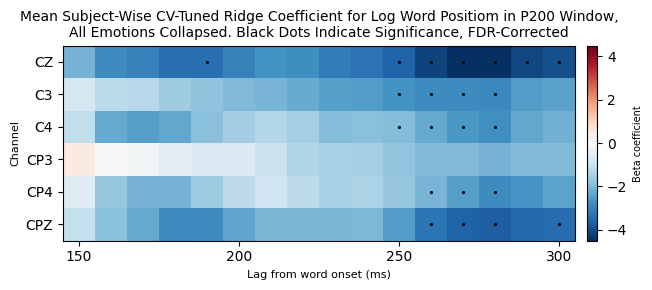

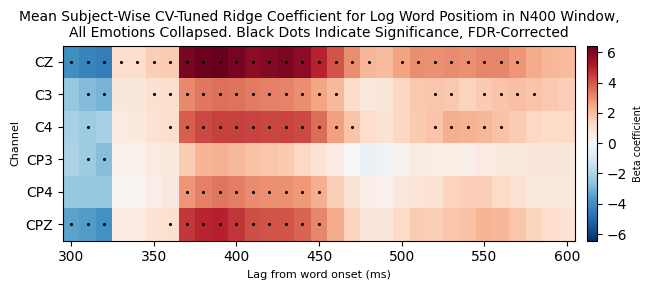

In [224]:
fig1 = time_window_heatmap(p200_coefs,
                           time_window=(0.15, 0.3),
                           dt=10,
                           ch_roi=ch_roi,
                           show_corrected=True,
                           component_name="P200")
fig2 = time_window_heatmap(n400_coefs,
                           time_window=(0.3, 0.6),
                           dt=10,
                           ch_roi=ch_roi,
                           show_corrected=True,
                           component_name="N400")
plt.show()

In [227]:
beta_n400_mean = np.mean(n400_coefs.beta_window, axis=-1)  # average over time window (last axis)
rows, p_vals = [], []
for j, ch in enumerate(ch_roi):
    vals = beta_n400_mean[:, j]
    res = ttest_1samp(vals, 0.0, alternative="greater")
    rows.append({"channel": ch,
                 "mean_beta": vals.mean(),
                 "median_beta": np.median(vals),
                 "t-statistc": res.statistic,
                 "p-val": res.pvalue,
                 "# coef > 0": np.sum(vals > 0),
                 "# coef <= 0": np.sum(vals <= 0),})
    p_vals.append(res.pvalue)
reject, q_vals = fdrcorrection(p_vals, alpha=0.05)
beta_summary = pd.DataFrame(rows)
beta_summary["q-val (fdr)"] = q_vals
beta_summary["H0 rejected (fdr)"] = reject
display(beta_summary)

,channel,mean_beta,median_beta,t-statistc,p-val,# coef > 0,# coef <= 0,q-val (fdr),H0 rejected (fdr)
0,CZ,2.828734,1.300237,4.202473,0.000094,27,7,0.000495,True
1,C3,1.539750,0.942591,3.233967,0.001386,26,8,0.002772,True
2,C4,1.932021,0.949023,4.006889,0.000165,25,9,0.000495,True
3,CP3,0.540550,0.175009,1.108888,0.137747,18,16,0.137747,False
4,CP4,1.151196,0.404489,2.450992,0.009856,19,15,0.011827,True
5,CPZ,1.725868,0.784540,2.725817,0.005093,23,11,0.007639,True


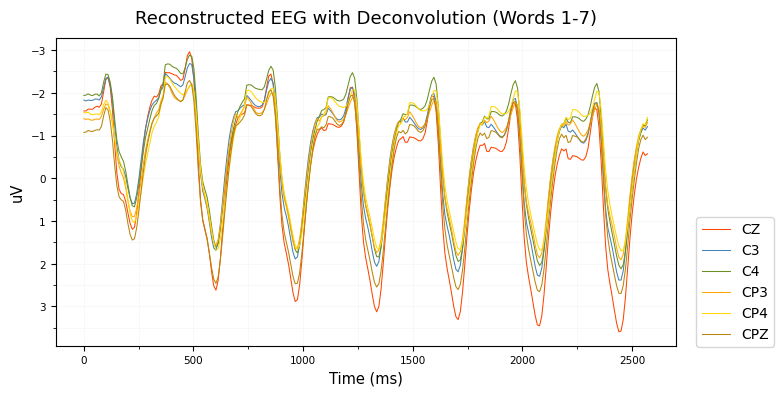

In [ ]:
colors = ["orangered", "steelblue", "olivedrab", "orange", "gold", "darkgoldenrod"]
downsampled_times = np.linspace(0.0, 2570.0, 257)

reconstruct = np.array([subj_refit[i].pred for i in range(len(subj_refit))])
reconstruct_mean = np.mean(reconstruct, axis=0)
fig, axes = plt.subplots(1, 1, figsize=(8, 4))

for (j, ch), color in zip(enumerate(ch_roi), colors):
    axes.plot(downsampled_times, reconstruct_mean[j, :], linewidth=0.75, label=ch, color=color)

axes.xaxis.set_minor_locator(AutoMinorLocator(2))
axes.yaxis.set_minor_locator(AutoMinorLocator(2))
axes.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1)
axes.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0)
    
axes.tick_params(axis="both", which="major", labelsize=7.5)
axes.legend(bbox_to_anchor=[0.67, -0.06, 0.5, 0.5])
axes.set_ylabel("uV", fontsize=10.5, x=0.05)
axes.set_xlabel("Time (ms)", fontsize=10.5, y=0.05)
axes.set_title("Reconstructed EEG with Deconvolution (Words 1-7)", y=1.02, fontsize=13)

plt.gca().invert_yaxis()
plt.show()

### Seperating emotions

In [205]:
arr_of_epochs_with_emo = [[e["w1/neu"],
                            e["w1/pos"],
                            e["w1/neg"]] for e in list_of_epochs]
arr_of_evokeds_with_emo = [[e.average(method="mean",
                                      by_event_type=False) for e in sublist]
                                         for sublist in arr_of_epochs_with_emo]
arr_of_epochs_with_emo = np.array(arr_of_epochs_with_emo, dtype=object)
arr_of_evokeds_with_emo = np.array(arr_of_evokeds_with_emo, dtype=object)

arr_of_matrices_with_emo = np.empty(arr_of_epochs_with_emo.shape, dtype=object)
for i in range(arr_of_epochs_with_emo.shape[0]):
    for j in range(arr_of_epochs_with_emo.shape[1]):
        arr_of_matrices_with_emo[i, j] = build_design(soa=SOA,
                                                      sfreq=DOWNSAMPLE_SFREQ,
                                                      n_words=N_WORDS, n_trials=len(arr_of_epochs_with_emo[i, j]),
                                                      response_lag=0.7,
                                                      rank_tol=1e-2,
                                                      intercept=True,
                                                      verbose=True,
                                                      word_pos=np.vstack([np.log(np.arange(1, N_WORDS+1))
                                                                          for _ in range(len(arr_of_epochs_with_emo[i, j]))]))
clear_output()
print(arr_of_epochs_with_emo.shape)
print(arr_of_evokeds_with_emo.shape)
print(arr_of_matrices_with_emo.shape)

(34, 3)
(34, 3)
(34, 3)


In [218]:
def loop_over_subjs(*, epochs_iterable: list|np.ndarray,
                    matrices_iterable: list|np.ndarray,
                    ch_roi: list,
                    alpha_range: np.array,
                    intercept_name: str="intercept",
                    ssp: bool=False, info: mne.Info | None=None,
                    n_splits_outer: int=5, n_splits_inner: int=5,
                    verbose_subj_idx: bool=True,
                    verbose_tuning: bool=False) -> tuple:
    """Loops over all subjects to compare full model (intercept + another predictor) with intercept-only model.
    Currently does not support comparision with a restricted model that is not intercept-only."""
    outer_scores_full_per_subj = np.empty((len(epochs_iterable), ), dtype=object)
    outer_scores_intercept_per_subj = np.empty((len(epochs_iterable), ), dtype=object)
    best_alphas_per_subj = []

    for i, (epochs, matrix) in enumerate(zip(epochs_iterable, matrices_iterable)):
        X_intercept = matrix.predictors[intercept_name]
        X_full = matrix.full
        subj_data = epochs.get_data(units="uV", picks=ch_roi)

        if verbose_subj_idx:
            print(f"subject index [{i}]...")
        if verbose_tuning:
            print(">> intercept-only")
        outer_scores_intercept, best_alphas_intercept = nested_cv(subj_data, X=X_intercept,
                                                                  ssp=ssp, info=info,
                                                                  alpha_range=alpha_range,
                                                                  n_splits_outer=n_splits_outer, n_splits_inner=n_splits_inner,
                                                                  ridge_tol=1e-4, solver="auto", max_iter=MAX_ITER,
                                                                  score_on_mean=False,
                                                                  verbose=verbose_tuning)
        outer_scores_intercept_per_subj[i] = outer_scores_intercept
        if verbose_tuning:
            print(">> full model")
        outer_scores_full, best_alphas_full = nested_cv(subj_data, X=X_full,
                                                       ssp=ssp, info=info,
                                                       alpha_range=alpha_range,
                                                       n_splits_outer=n_splits_outer, n_splits_inner=n_splits_inner,
                                                       ridge_tol=1e-4, solver="auto", max_iter=MAX_ITER,
                                                       score_on_mean=False,
                                                       verbose=verbose_tuning)
        outer_scores_full_per_subj[i] = outer_scores_full
        best_alphas_per_subj.append((best_alphas_intercept, best_alphas_full))
    
    LoopResults = namedtuple("LoopResults", ["outer_scores_full_per_subj",
                                             "outer_scores_intercept_per_subj",
                                             "best_alphas_per_subj"])
    loop_results = LoopResults(outer_scores_full_per_subj, outer_scores_intercept_per_subj, best_alphas_per_subj)
    return loop_results


def refit_all_subjs(*, epochs_iterable: list|np.ndarray,
                    evokeds_iterable: list|np.ndarray,
                    matrices_iterable: list|np.ndarray,
                    matrix_refit: DeconvDesignMatrix,
                    ch_roi: list,
                    alpha_range: np.array,
                    ssp: bool=False, info: mne.Info|None=None,
                    n_splits: int=5,
                    ridge_tol: float=1e-4, solver: str="auto", max_iter: int|None=None,
                    verbose: bool=True) -> tuple:
    X_refit = matrix_refit.full
    if verbose:
        print(X_refit.shape)
    
    subj_alpha_tuned, subj_refit = [], []
    for i, (epochs, evoked, matrix) in enumerate(zip(epochs_iterable, evokeds_iterable, matrices_iterable)):
        if verbose:
            print(f"subject index [{i}]...")
        subj_epochs_data = epochs.get_data(units="uV", picks=ch_roi)
        subj_evoked_data = evoked.get_data(units="uV", picks=ch_roi)
        X_tune = matrix.full
        cv_results, refit_results = refit(subj_epochs_data,
                                          X_tune=X_tune, X_refit=X_refit,
                                          ch_roi=ch_roi,
                                          alpha_range=alpha_range,
                                          ssp=ssp, info=info,
                                          n_splits=n_splits,
                                          ridge_tol=ridge_tol,
                                          solver=solver,
                                          max_iter=max_iter,
                                          subj_data_mean=subj_evoked_data)
        subj_alpha_tuned.append(cv_results)
        subj_refit.append(refit_results)
    return subj_alpha_tuned, subj_refit




In [209]:
ch_roi = ["CZ", "C3", "C4", "CP3", "CP4", "CPZ"]
ch_roi_to_idx = {ch: idx for idx, ch in enumerate(list_of_epochs[0].ch_names)}
alpha_range = np.logspace(-3, 3, 25)  # 0.001 -> 1000

per_emo_condition = dict()
emotions = ["neu", "pos", "neg"]
for j in range(arr_of_epochs_with_emo.shape[1]):
    print(f"**EMOTION = {emotions[j].upper()}**")
    res = loop_over_subjs(epochs_iterable=arr_of_epochs_with_emo[:, j],
                          matrices_iterable=arr_of_matrices_with_emo[:, j],
                          ch_roi=ch_roi,
                          alpha_range=alpha_range,
                          intercept_name="intercept",
                          ssp=False, info=None,
                          n_splits_outer=5, n_splits_inner=5,
                          verbose_subj_idx=True,
                          verbose_tuning=False)
    per_emo_condition[emotions[j]] = res
    clear_output()

In [ ]:
improve_dfs_with_emo = {key: compare_model_fit(per_emo_condition[key].outer_scores_full_per_subj,
                                               per_emo_condition[key].outer_scores_intercept_per_subj,
                                               ch_roi) for key in per_emo_condition.keys()}
for key, df in improve_dfs_with_emo.items():
    print(f"**EMOTIONS = {key.upper()}**")
    display(df)

**EMOTIONS = NEU**


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.067292,0.054219,0.013073,3.050476,0.002242,0.006725
C3,0.056924,0.046324,0.010600,2.698189,0.005450,0.008176
C4,0.055887,0.044806,0.011081,2.446400,0.009963,0.009963
CP3,0.048156,0.038026,0.010130,2.775135,0.004508,0.008176
CP4,0.046623,0.037742,0.008881,2.508665,0.008605,0.009963
CPZ,0.052903,0.043250,0.009654,3.312478,0.001125,0.006725


**EMOTIONS = POS**


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.052699,0.039544,0.013156,2.536229,0.008060,0.021330
C3,0.040105,0.029626,0.010479,2.201752,0.017391,0.021330
C4,0.044715,0.031500,0.013215,2.522648,0.008325,0.021330
CP3,0.031032,0.021518,0.009514,2.191884,0.017775,0.021330
CP4,0.034974,0.025828,0.009145,2.101039,0.021679,0.021679
CPZ,0.038121,0.029065,0.009056,2.378954,0.011651,0.021330


**EMOTIONS = NEG**


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.061112,0.047777,0.013335,2.325346,0.013174,0.026749
C3,0.048486,0.038560,0.009926,2.002553,0.026749,0.026749
C4,0.048325,0.036700,0.011625,2.135166,0.020131,0.026749
CP3,0.041544,0.032356,0.009188,2.045171,0.024440,0.026749
CP4,0.034259,0.025709,0.008550,2.082155,0.022579,0.026749
CPZ,0.046112,0.035834,0.010278,2.469426,0.009439,0.026749


In [222]:
matrix_refit = build_design(soa=SOA,
                      sfreq=DOWNSAMPLE_SFREQ,
                      n_words=N_WORDS, n_trials=1,
                      response_lag=0.7,
                      rank_tol=1e-2,
                      intercept=True,
                      verbose=True,
                      word_pos=np.log(np.arange(1, N_WORDS+1))[np.newaxis, :])
X_refit = matrix_refit.full
print(X_refit.shape)

per_emo_condition_refit = dict()
for j in range(arr_of_epochs_with_emo.shape[1]):
    print(f"**EMOTION = {emotions[j].upper()}**")
    res = refit_all_subjs(epochs_iterable=arr_of_epochs_with_emo[:, j],
                          evokeds_iterable=arr_of_evokeds_with_emo[:, j],
                          matrices_iterable=arr_of_matrices_with_emo[:, j],
                          matrix_refit=matrix_refit,
                          ch_roi=ch_roi,
                          alpha_range=alpha_range,
                          ssp=False, info=None,
                          n_splits=5,
                          ridge_tol=RIDGE_TOL, solver="auto", max_iter=MAX_ITER,
                          verbose=True)
    per_emo_condition_refit[emotions[j]] = res
    
    clear_output()



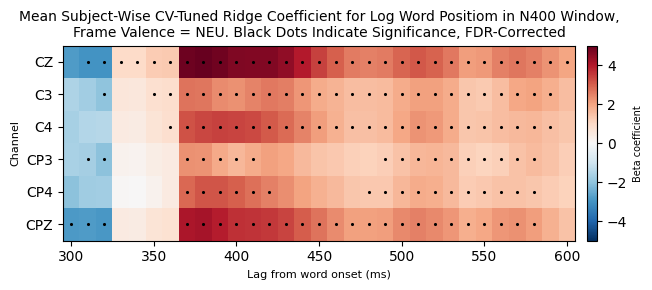

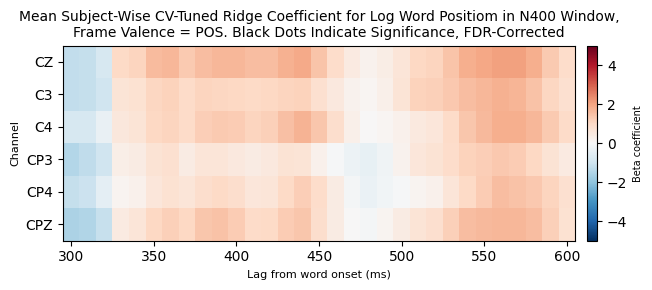

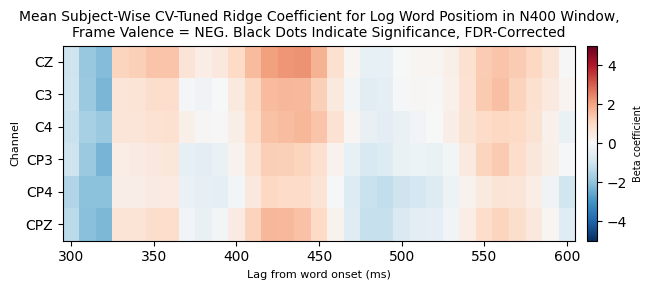

In [229]:
n400_coefs_with_emo = {key: get_time_window_coefs(val[1],
                                                  n_predictors=2,
                                                  intercept_index=0,
                                                  beta_index=1,
                                                  time_window=(0.3, 0.6),
                                                  sfreq=100.0,
                                                  sig_thresh=0.05)
                                                  for key, val in per_emo_condition_refit.items()}
figs_with_emo = {key: time_window_heatmap(coefs,
                                          time_window=(0.3, 0.6),
                                          dt=10,
                                          ch_roi=ch_roi,
                                          show_corrected=True,
                                          vmin=-5, vmax=5,
                                          component_name="N400",
                                          emotion_category=f"Frame Valence = {key.upper()}")
                                          for key, coefs in n400_coefs_with_emo.items()}